## Trabajo Práctico
### Modelo de clasificación
#### Aprendizaje Automático I

**Carga de librerías**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Carga de datos**

In [2]:
data = pd.read_csv('weatherAUS.csv')

#### Análisis EDA

Muestra de datos generales.

In [3]:
data.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

**Variables Generales**
- Date: Fecha de la observación.
- Location: La ubicación o ciudad en Australia.

**Variables de Temperatura, en °C**
- MinTemp: Temperatura mínima del día.
- MaxTemp: Temperatura máxima del día.
- Temp9am: Temperatura registrada a las 9 de la mañana.
- Temp3pm: Temperatura registrada a las 3 de la tarde.

**Variables de Precipitación y Humedad**
- Rainfall: La cantidad de lluvia registrada ese día, en mm.
- Evaporation: Evaporación de agua de "Clase A" en las 24 horas hasta las 9 am, en milímetros (mm).
- Sunshine: El número de horas de sol brillante durante el día.
- Humidity9am: La humedad relativa a las 9 de la mañana, como un porcentaje.
- Humidity3pm: La humedad relativa a las 3 de la tarde, como un porcentaje.
- RainToday: Indica si hubo precipitación (más de 1 mm) en ese día, o no.

**Variables de Viento**
- WindGustDir: La dirección de la ráfaga de viento más fuerte del día (ej. N, S, SW).
- WindGustSpeed: La velocidad de la ráfaga de viento más fuerte del día, en km/h.
- WindDir9am: La dirección del viento a las 9 de la mañana.
- WindDir3pm: La dirección del viento a las 3 de la tarde.
- WindSpeed9am: La velocidad promedio del viento, a las 9 de la mañana, en km/h.
- WindSpeed3pm: La velocidad promedio del viento a las 3 de la tarde, en km/h.

**Variables Atmosféricas**
- Pressure9am: La presión atmosférica a nivel del mar a las 9 de la mañana, medida en hectopascales (hPa).
- Pressure3pm: La presión atmosférica a las 3 de la tarde, en hPa.
- Cloud9am: La fracción del cielo cubierta por nubes a las 9 de la mañana. Se mide en "oktas", una escala de 0 (cielo completamente despejado) a 8 (cielo completamente cubierto).
- Cloud3pm: La fracción del cielo cubierta por nubes a las 3 de la tarde.

**Variable Objetivo**

*RainTomorrow*: Variable categórica ('Yes'/'No') que responde a la pregunta: "¿Llovió al día siguiente?".

Para agilizar la limpieza, se verifica si hay registros con solo valores nulos.

In [5]:
data.isna().all(axis=1).any()

False

No hay registros solo con datos nulos. Se verifica cuáles tienen nulos y qué porcentaje representa del total.

In [6]:
porc_nulos = data.isnull().sum()/len(data)*100

In [7]:
col_nulos = porc_nulos[porc_nulos>0].sort_values(ascending=False)

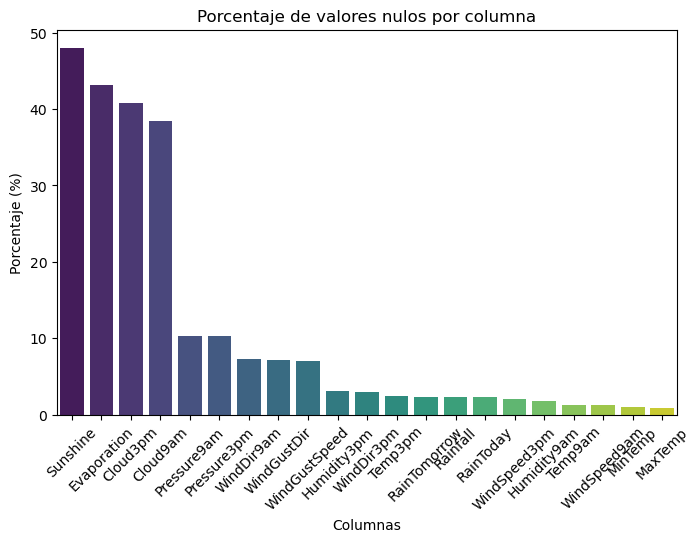

In [8]:
plt.figure(figsize=(8,5))
sns.barplot(x=col_nulos.index, y=col_nulos.values, palette='viridis')

plt.title('Porcentaje de valores nulos por columna')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Columnas')
plt.xticks(rotation=45)
plt.show()

Distribución de datos numéricos en histogramas.

In [9]:
data_num = data[['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 
                 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
                 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']]

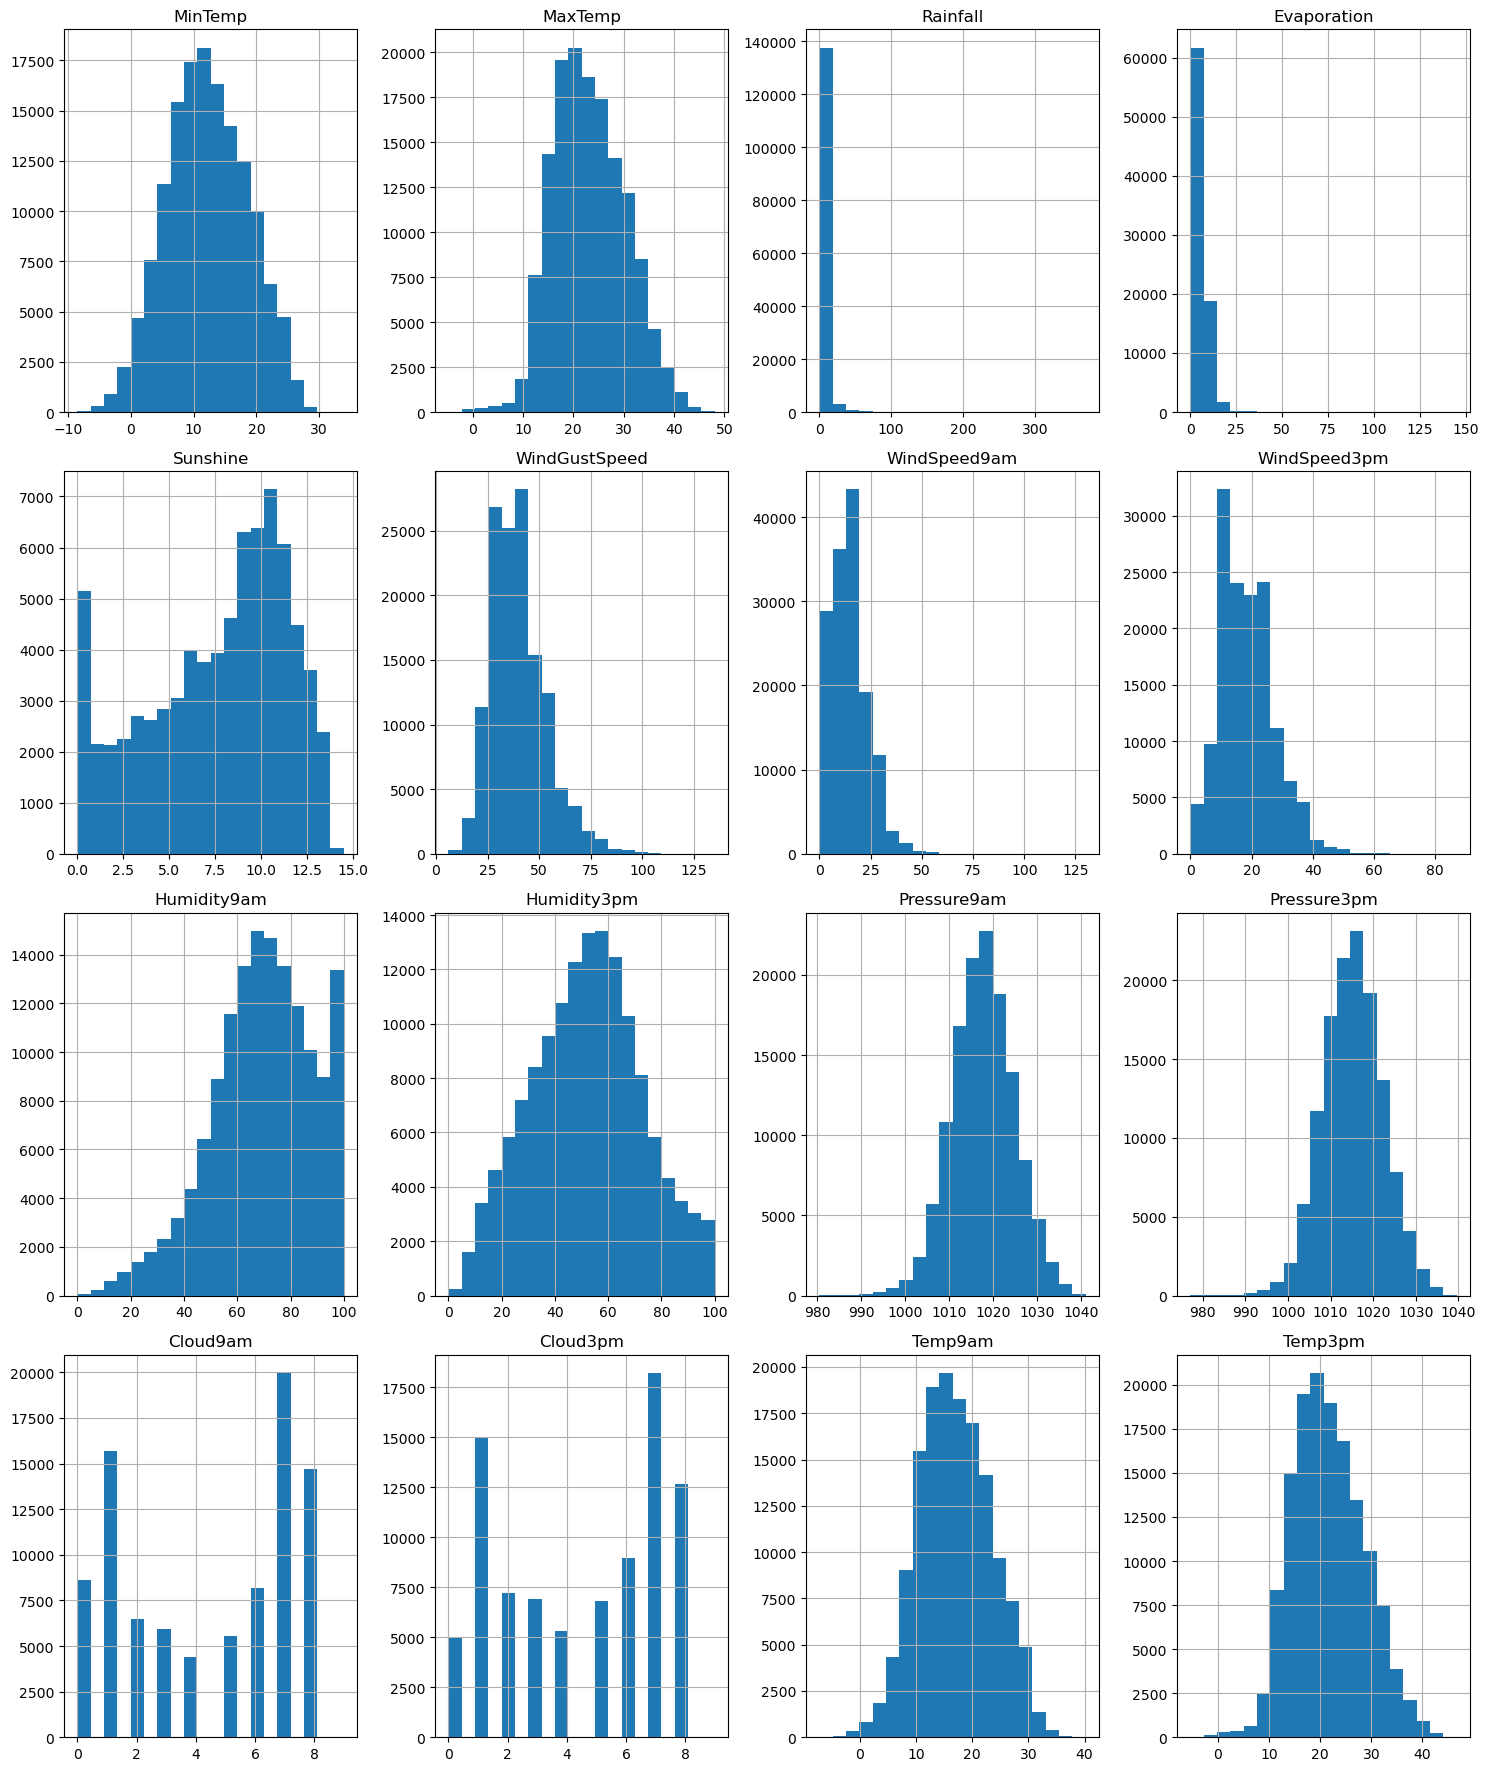

In [10]:
data_num.hist(figsize=(15, 22), bins=20, layout=(5, 4))
plt.tight_layout()
plt.show()

De las variables numéricas, las siguientes tienen una **distribución simétrica o apróximadamente normal**: MinTemp, MaxTemp, Humidity3pm, Pressure9am, Pressure3pm, Temp9am, Temp3pm.

Por otro lado, las siguientes hay una **distribución asimétrica con cola a la derecha**: Rainfall, Evaporation, WindGustSpeed, WindDir9am, WindDir3pm, WindSpeed9am, WindSpeed3pm.

Asimismo, hay **distribuciones asimétricas con cola a la izquierda**: Humidity9am.

Finalmente, hay **distribuciones diferentes** a las nombradas: Sunshine (bimodal) y Cloud9am y Cloud3pm (discretas multimodales, con concentración en los extremos).

Detalles sobre las columnas categóricas.

In [11]:
data_cat = data[['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'RainTomorrow']]

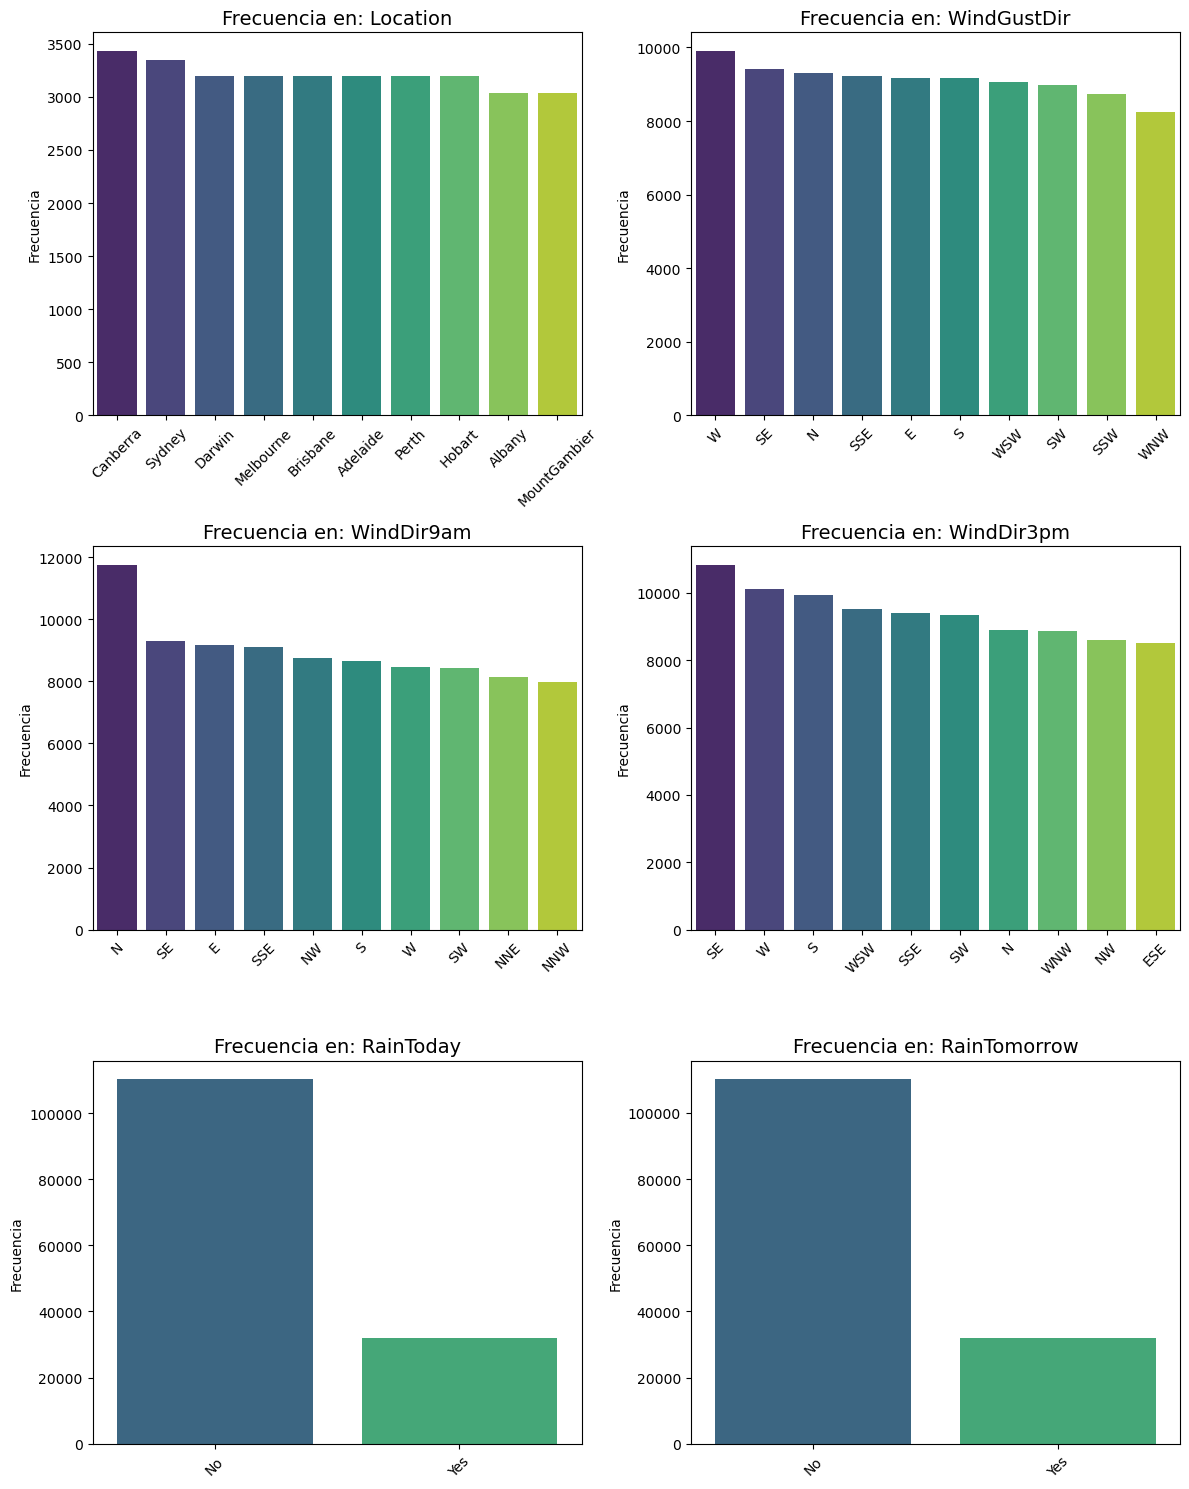

In [12]:
import math

n_cols = 2
n_rows = math.ceil(data_cat.shape[1] / n_cols)

fig, axes = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(12, n_rows * 5))
axes = axes.flatten()

# Se itera sobre cada columna categórica y crear su gráfico
for i, col in enumerate(data_cat.columns):
    top_cat = data_cat[col].value_counts().nlargest(10)
    
    sns.barplot(x=top_cat.index, y=top_cat.values, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Frecuencia en: {col}', fontsize=14)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Imputación de errores o datos faltantes

Teniendo encuenta lo visto por .info(), se elige cambiar los tipos de datos de Date, RainToday y RainTomorrow en formatos más útiles para el futuro modelo predictivo (datetime y 1/0, respectivamente).

In [13]:
data_limpio = data.copy()

In [14]:
data_limpio['Date'] = pd.to_datetime(data_limpio['Date'])

In [15]:
map_val = {'Yes': 1, 'No': 0}
data_limpio['RainToday'] = data_limpio['RainToday'].map(map_val)
data_limpio['RainTomorrow'] = data_limpio['RainTomorrow'].map(map_val)

Teniendo en cuenta lo visto en el análisis EDA, se observan con detalle las columnas con más nulos: Sunshine, Evaporation, Cloud3pm, Cloud9am.

In [16]:
cols_nulos = ['Sunshine', 'Evaporation', 'Cloud9am', 'Cloud3pm']

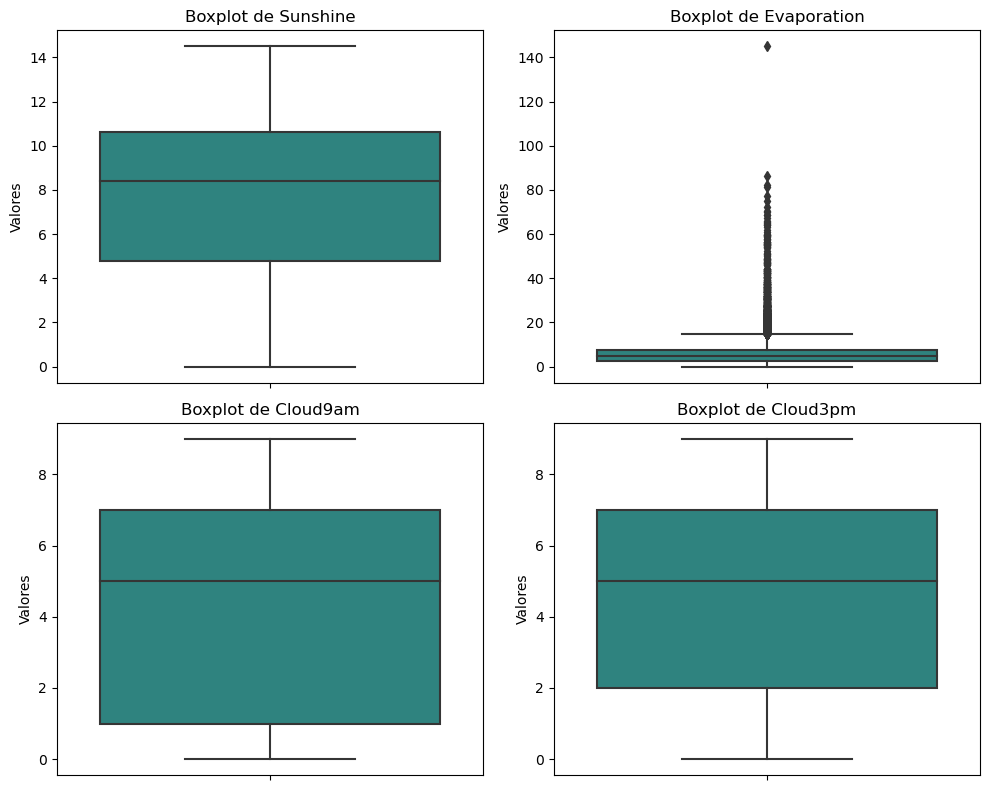

In [17]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
axes = axes.flatten()

for i, col in enumerate(cols_nulos):
    sns.boxplot(y=data[col], ax=axes[i], palette='viridis')
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel('Valores')

plt.tight_layout()
plt.show()

En base a lo visto en estas variables con más nulos, de forma al menos provisoria, se elige imputar dichos nulos con el valor de la mediana no solo a estas sino también a todas las variables numéricas.

In [18]:
from sklearn.impute import SimpleImputer

In [19]:
imputer_mediana = SimpleImputer(strategy='median')


In [20]:
col_num = ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 
                 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
                 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']

In [21]:
data_limpio[col_num] = imputer_mediana.fit_transform(data_limpio[col_num])

Al ser relevantes, se comienza explorando más información sobre las ciudades del dataset. Al solo contar con sus nombres, se buscan sus latitudes y longitudes para visualizarlas.

In [22]:
data_limpio['Location'] = data_limpio['Location'].str.strip()

In [23]:
import geonamescache

In [24]:
gc = geonamescache.GeonamesCache()
ciudades = gc.get_cities()

In [25]:
ciudades_df = pd.DataFrame(ciudades).T

In [26]:
ciudades_df = ciudades_df[["name", "countrycode", "latitude", "longitude"]]
ciudades_df.rename(columns={"name": "Location"}, inplace=True)

In [27]:
data_completo = pd.merge(data_limpio, ciudades_df, on='Location', how='left')

Visualización de ciudades en mapa

In [28]:
import geopandas as gpd
import contextily as ctx

In [29]:
def crear_geodf(df, lon_col="longitude", lat_col="latitude"):
    """
    Convierte un DataFrame con columnas de latitud/longitud
    en un GeoDataFrame en proyección métrica (EPSG:3857)
    """
    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
        crs="EPSG:4326"  # coordenadas geográficas
    )
    return gdf.to_crs(epsg=3857)

In [30]:
gdf = crear_geodf(data_completo)

In [31]:
def graf_mapa(geodf, titulo):
    fig, ax = plt.subplots(figsize=(10, 8))
    geodf.plot(ax=ax, color='red', markersize=60)

    # Mapa base
    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

    # Límites del mapa
    ax.set_xlim(geodf.total_bounds[0] - 1e6, geodf.total_bounds[2] + 1e6)
    ax.set_ylim(geodf.total_bounds[1] - 1e6, geodf.total_bounds[3] + 1e6)

    ax.set_title(titulo, fontsize=14)
    plt.show()

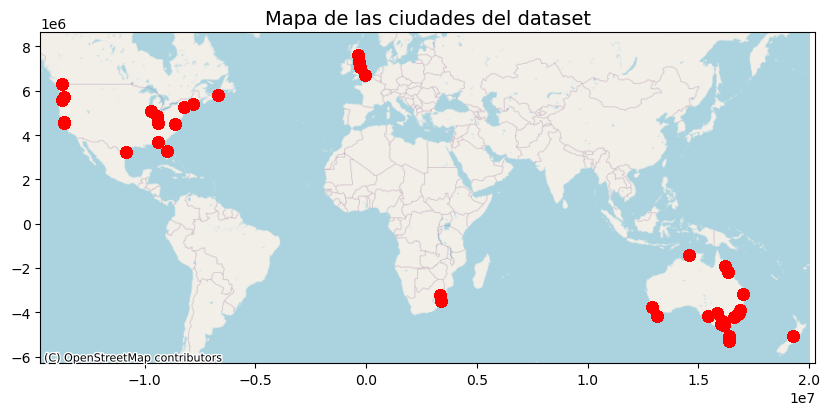

In [32]:
titulo = 'Mapa de las ciudades del dataset'
graf_mapa(gdf, titulo)

Como el presente análisis solo se centrará en Australia, se limitará a las ciudades situadas entre:
- Latitud: entre -44 y -10
- Longitud: entre 113 y 154.

In [33]:
def in_aus(lat, lon):
    return -44 <= lat <= -10 and 113 <= lon <= 154

# Filtro solo Australia
mask = data_completo.apply(lambda row: in_aus(row['latitude'], row['longitude']), axis=1)

data_aus = data_completo[mask].copy()

In [34]:
gdf = crear_geodf(data_aus)

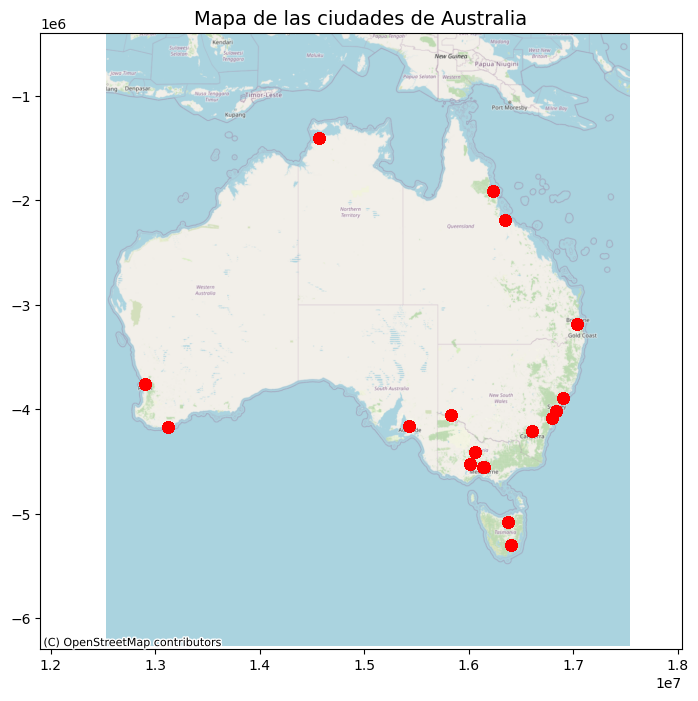

In [35]:
titulo = 'Mapa de las ciudades de Australia'
graf_mapa(gdf, titulo)

Ahora que solo quedaron los datos relacionados a Australia, se continúa con la clusterización de las regiones. Se hipotetiza que se propia dividir el mapa en cuatro regiones (norte, sur, este y oeste) pero se verificará con el método del codo.

In [36]:
from sklearn.cluster import KMeans

In [37]:
x = data_aus[['latitude', 'longitude']]

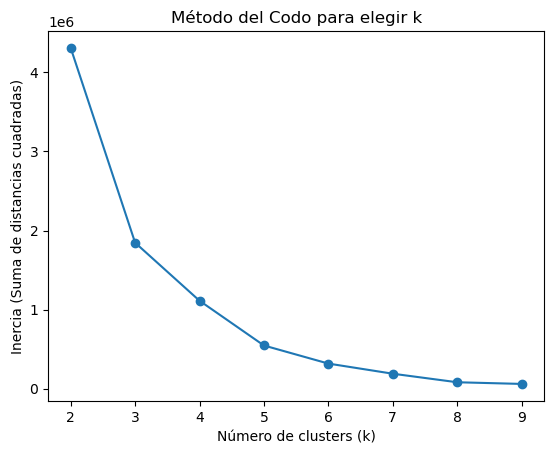

In [38]:
inertias = []
for k in range(2, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(x)
    inertias.append(km.inertia_)

plt.plot(range(2, 10), inertias, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia (Suma de distancias cuadradas)')
plt.title('Método del Codo para elegir k')
plt.show()

El método del codo demuestra que es mejor 6 que 4. Se graficará esta idea.

In [39]:
k = 6
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
data_aus['region_cluster'] = kmeans.fit_predict(x)

Graficación de resultados de clusters

In [40]:
gdf = crear_geodf(data_aus)

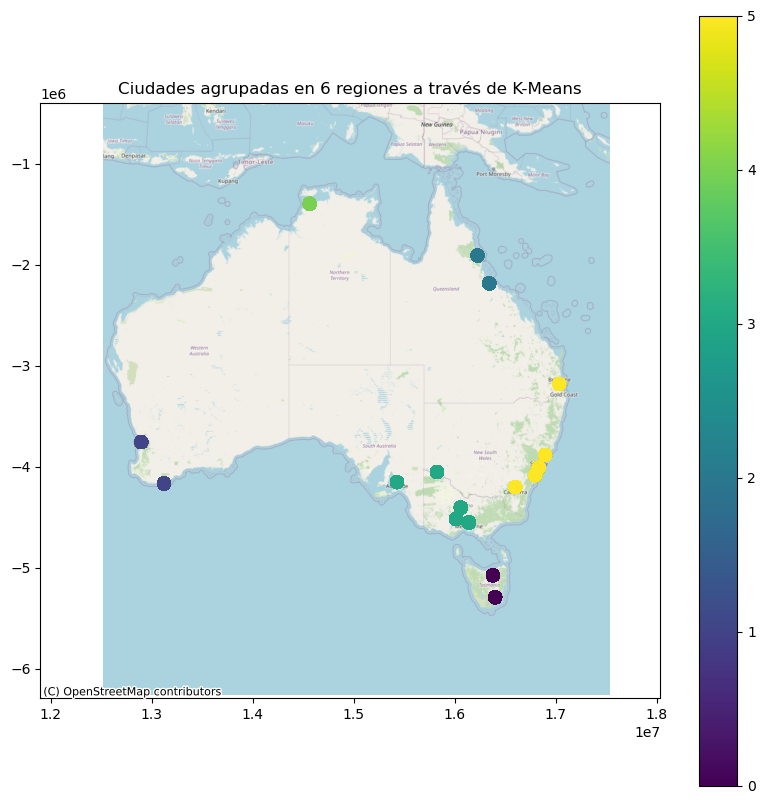

In [41]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, column="region_cluster", legend=True, markersize=80, alpha=0.9)
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
ax.set_xlim(gdf.total_bounds[0] - 1e6, gdf.total_bounds[2] + 1e6)
ax.set_ylim(gdf.total_bounds[1] - 1e6, gdf.total_bounds[3] + 1e6)
ax.set_title(f"Ciudades agrupadas en {k} regiones a través de K-Means", fontsize=12)
plt.show()